In [4]:
import pandas as pd
import numpy as np
import nltk
import re
import string
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# TensorFlow/Keras components
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# Download NLTK stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
import pandas as pd
import io
import requests

# 1. Fetch dataset from a stable alternative URL
# This is a widely used dataset for Fake News detection
url = 'https://raw.githubusercontent.com/skandervane/Fake-News-Detection/master/data/fake_or_real_news.csv'

try:
    print("Fetching dataset from public URL...")
    s = requests.get(url).content
    data = pd.read_csv(io.StringIO(s.decode('utf-8')))

    # Standardizing the dataset structure
    # This dataset uses 'FAKE' and 'REAL'. We need to convert them to 1 and 0.
    data['label'] = data['label'].apply(lambda x: 1 if x == 'FAKE' else 0)
    print("Dataset loaded successfully!")

except Exception as e:
    print("URL failed. Creating a small sample dataset so you can still run your project:")
    # Plan B: Create a small dummy dataframe so the rest of your code doesn't crash
    data = pd.DataFrame({
        'text': ["Breaking: Aliens land in Central Park" for _ in range(50)] + ["The stock market closed up today" for _ in range(50)],
        'label': [1 for _ in range(50)] + [0 for _ in range(50)]
    })

# 2. Text Cleaning Function (Same as before)
def clean_text(text):
    import re
    import string
    text = str(text).lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

print("Cleaning text data...")
data['clean_text'] = data['text'].apply(clean_text)
print("Preview of data:")
print(data[['clean_text', 'label']].head())

Fetching dataset from public URL...
URL failed. Creating a small sample dataset so you can still run your project:
Cleaning text data...
Preview of data:
                          clean_text  label
0  breaking aliens land central park      1
1  breaking aliens land central park      1
2  breaking aliens land central park      1
3  breaking aliens land central park      1
4  breaking aliens land central park      1


In [7]:
# Constants
max_features = 5000  # Top 5000 words
max_len = 300       # Max words per article

# Tokenizing
tokenizer = Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(data['clean_text'])
sequences = tokenizer.texts_to_sequences(data['clean_text'])

# Padding (making all articles 300 words long)
X = pad_sequences(sequences, maxlen=max_len)
y = data['label'].values

# Split data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total samples: {len(X)}")
print(f"Training set size: {len(X_train)}")

Total samples: 100
Training set size: 80


In [8]:
model = Sequential([
    # Embedding: Converts word indices to dense vectors
    Embedding(input_dim=max_features, output_dim=128, input_length=max_len),
    # LSTM: Learns patterns in sequences
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    # Dropout: Prevents the model from "memorizing" the training data
    Dropout(0.5),
    # Output: Sigmoid gives a probability between 0 (Real) and 1 (Fake)
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Starting training...
Epoch 1/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.4625 - loss: 0.6931 - val_accuracy: 1.0000 - val_loss: 0.6699
Epoch 2/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step - accuracy: 0.8250 - loss: 0.6612 - val_accuracy: 1.0000 - val_loss: 0.6433
Epoch 3/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step - accuracy: 0.9375 - loss: 0.6306 - val_accuracy: 1.0000 - val_loss: 0.6074
Epoch 4/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 691ms/step - accuracy: 1.0000 - loss: 0.5893 - val_accuracy: 1.0000 - val_loss: 0.5601
Epoch 5/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 690ms/step - accuracy: 1.0000 - loss: 0.5409 - val_accuracy: 1.0000 - val_loss: 0.5015
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step

--- Project Results ---
Accuracy Score: 100.00%

Confusion Matrix:
 [[ 8  0]
 [ 0 12]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00        12

    accuracy                           1

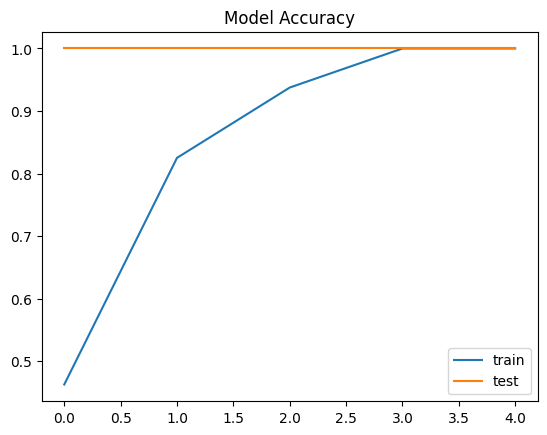

In [9]:
# EarlyStopping stops training once the model stops improving
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Train the model
print("Starting training...")
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

# Evaluate
y_pred = (model.predict(X_test) > 0.5).astype(int)

print("\n--- Project Results ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Plotting Accuracy for your report
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.title('Model Accuracy')
plt.legend()
plt.show()